In [19]:
!pip install tensorflow

In [20]:
import tensorflow as tf



In [21]:
#step 1 : load dataset 
mnist = tf.keras.datasets.mnist
#(train_images , train_labels), (test_images, test_labels) = mnist.load_data()
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [22]:
print("train images shape:", x_train.shape)
print("train labels shape:",y_train.shape)
print("test images shape:",x_test.shape)
print("test labels shape:",y_test.shape)

      

train images shape: (60000, 28, 28)
train labels shape: (60000,)
test images shape: (10000, 28, 28)
test labels shape: (10000,)


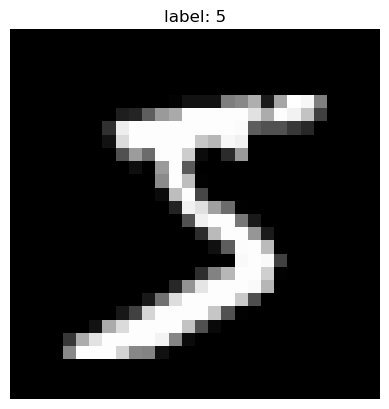

In [23]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0],cmap = "gray")
plt.title(f"label: {y_train[0]}")
plt.axis("off")
plt.show()

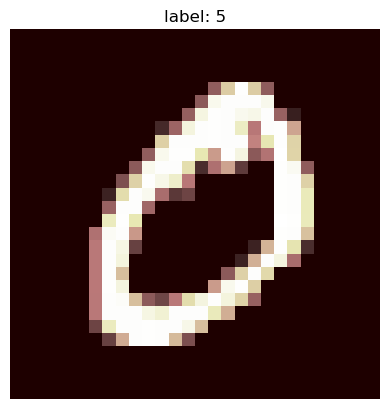

In [24]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1],cmap = "pink")
plt.title(f"label: {y_train[0]}")
plt.axis("off")
plt.show()

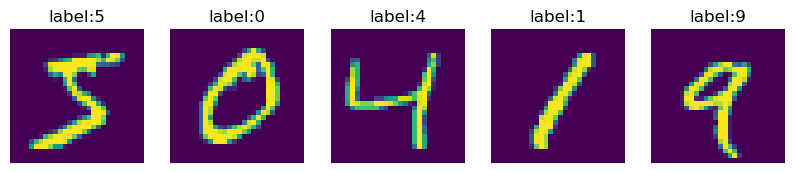

In [25]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(f"label:{y_train[i]}")
    plt.axis("off")
plt.show()

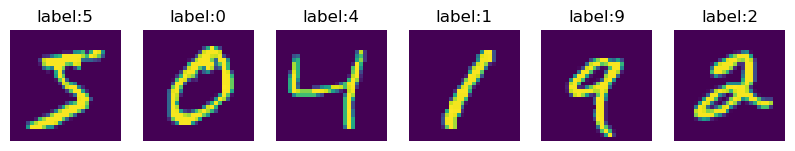

In [26]:
plt.figure(figsize=(10,2))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(x_train[i])
    plt.title(f"label:{y_train[i]}")
    plt.axis("off")
plt.show()

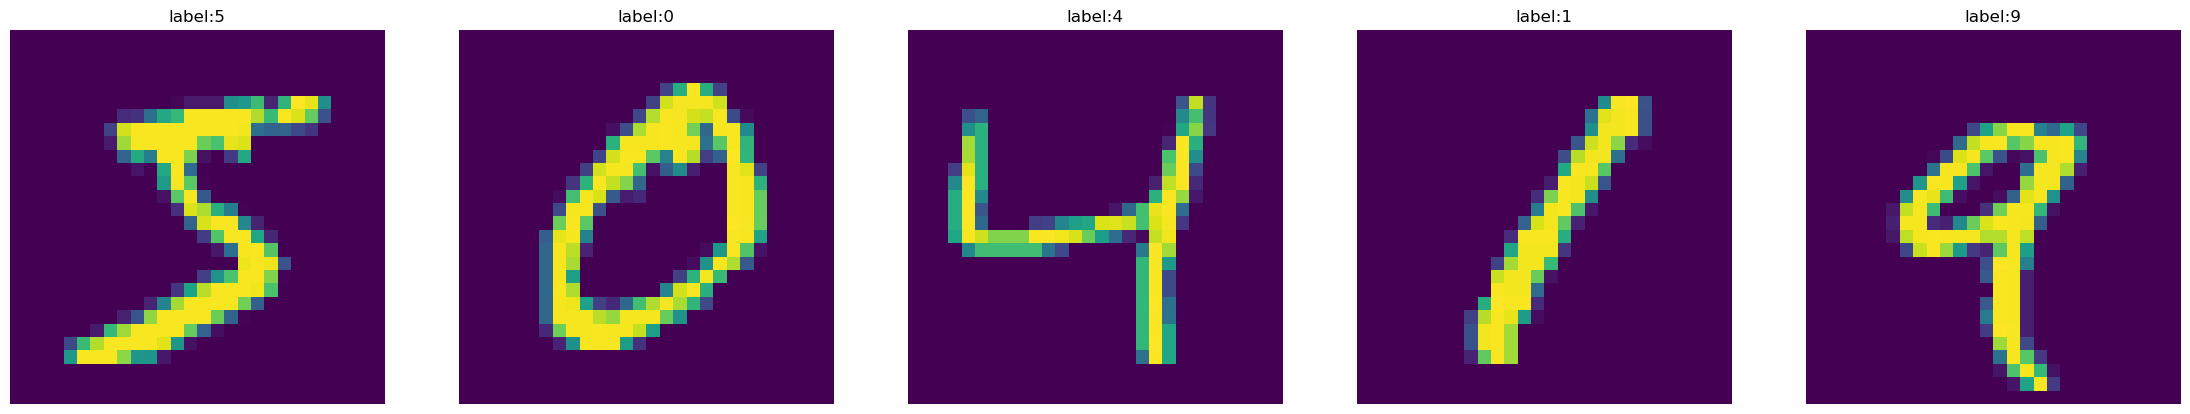

In [27]:
plt.figure(figsize=(28,28))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(f"label:{y_train[i]}")
    plt.axis("off")
plt.show()

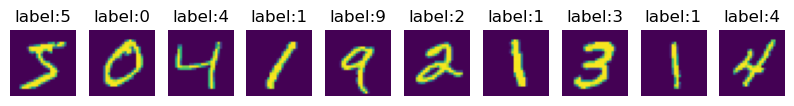

In [28]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i])
    plt.title(f"label:{y_train[i]}")
    plt.axis("off")
plt.show()

In [ ]:
#step 2 : normalize values(0 to 1)
train_images = x_train/255.0
test_images = x_test/255.0

In [ ]:
#step 3 : add channel dimension (important for cnn)
train_images = train_images.reshape((60000,28,28,1))
test_images = test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation = "relu",input_shape =(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(32, activation = "relu"),
    layers.Dense(10, activation = "softmax")
])

In [ ]:
#step 5 = compile model
model.compile(optimizer= "adam",
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

# step6 : train model
model.fit(train_images, y_train, epochs = 3)

In [ ]:
#step 7 = test model
test_loss , test_acc = model.evaluate(test_images, y_test)
print("accuracy:",test_acc)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability


In [ ]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, y_train, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, y_test)
print("Accuracy:", test_acc)